# Generate your own synthetic data with DP-CGANS

**Unlock Your Sensitive Data** · TDCC-SSH workshop · 14 October 2026

Run the cells from top to bottom with **Shift+Enter**. In 15 minutes you will train a generator on a small public dataset, create synthetic rows from it, look at how close they are to the real data, and switch differential privacy on.

## 1. Install the package

In [1]:
%%capture
!pip install dp-cgans

## 2. Load the data

Census income data on 2 000 adults: age, education, marital status, sex, type of employer, working hours and income. Public data, so nothing sensitive here. Think of it as a stand-in for a survey you are not allowed to share.

In [2]:
import pandas as pd

tabular_data = pd.read_csv("https://raw.githubusercontent.com/sunchang0124/syndata-workshop/main/data/census_workshop.csv").sample(2000, random_state=0)
tabular_data.head()

,age,education,marital_status,sex,workclass,hours_per_week,income
27725,31,High school,Never married,Female,Private,58,low
20217,24,Some college,Never married,Female,Private,42,low
13826,24,High school,Never married,Male,Self-employed,35,low
41685,30,Some college,Married,Female,Private,40,low
28634,38,High school,Married,Male,Private,40,low


## 3. Train the generator

This is the usage example from the package documentation. Forty rounds of training takes about a minute. Watch the progress bar.

In [3]:
from dp_cgans import DP_CGAN
import time, os

if os.path.exists("fitted_transformer.pkl"):   # the package reuses an old transformer if it finds one; start fresh
    os.remove("fitted_transformer.pkl")

model = DP_CGAN(
    epochs=40,            # number of training rounds
    batch_size=500,       # rows per training step
    private=False,        # differential privacy off for now
    verbose=False,
    saved_transformer=None,
)

start_time = time.time()
model.fit(tabular_data)
print("Training took", round(time.time() - start_time), "seconds")

model.save("generator.pkl")

ssss
Start transforming data...
No transformer path provided.
Start fitting new transformer ...
Saving fitted transformer...
Finish transforming data / loading transformed data...
Training Configuration:
  Batch size: 500
  Steps per epoch: 4
  Generator dim: (256, 256)
  Discriminator dim: (256, 256)
  Device: cpu
  Data shape: (2000, 39)
  Prefetching: DISABLED (direct sampling - threading caused contention)
2026-10-07 12:47:30.364701 epoch:    0%|          | 0/40 [00:00<?, ?it/s]

  DETAILED FIRST EPOCH TIMING BREAKDOWN
DISCRIMINATOR TRAINING:
  Data fetching:    0.12s (  8.7%) - avg   29.5ms
  Forward pass:     0.18s ( 13.3%) - avg   45.3ms
  Backward pass:    0.20s ( 14.4%) - avg   49.2ms

GENERATOR TRAINING:
  Data fetching:    0.10s (  7.4%) - avg   25.3ms
  Forward pass:     0.06s (  4.6%) - avg   15.7ms
  Cond loss calc:   0.25s ( 18.7%) - avg   63.7ms
  Backward pass:    0.45s ( 32.9%) - avg  112.0ms

SUMMARY:
  Total measured:   1.36s (100.0%)
  Unmeasured:       0.00s (  0.

## 4. Generate synthetic rows

In [4]:
syn_data = model.sample(2000)
syn_data.to_csv("syn_data_file.csv", index=None)
syn_data.head()

,age,education,marital_status,sex,workclass,hours_per_week,income
0,41,High school,Previously married,Female,Private,50,low
1,71,High school,Previously married,Male,Private,47,low
2,39,Some college,Married,Female,Private,41,low
3,27,High school,Never married,Male,Private,46,low
4,32,Bachelor or higher,Married,Male,Private,55,low


## 5. Does it look like the real data?

Blue is real, orange is synthetic. After only 40 rounds the generator knows the categories but usually not yet the right proportions.

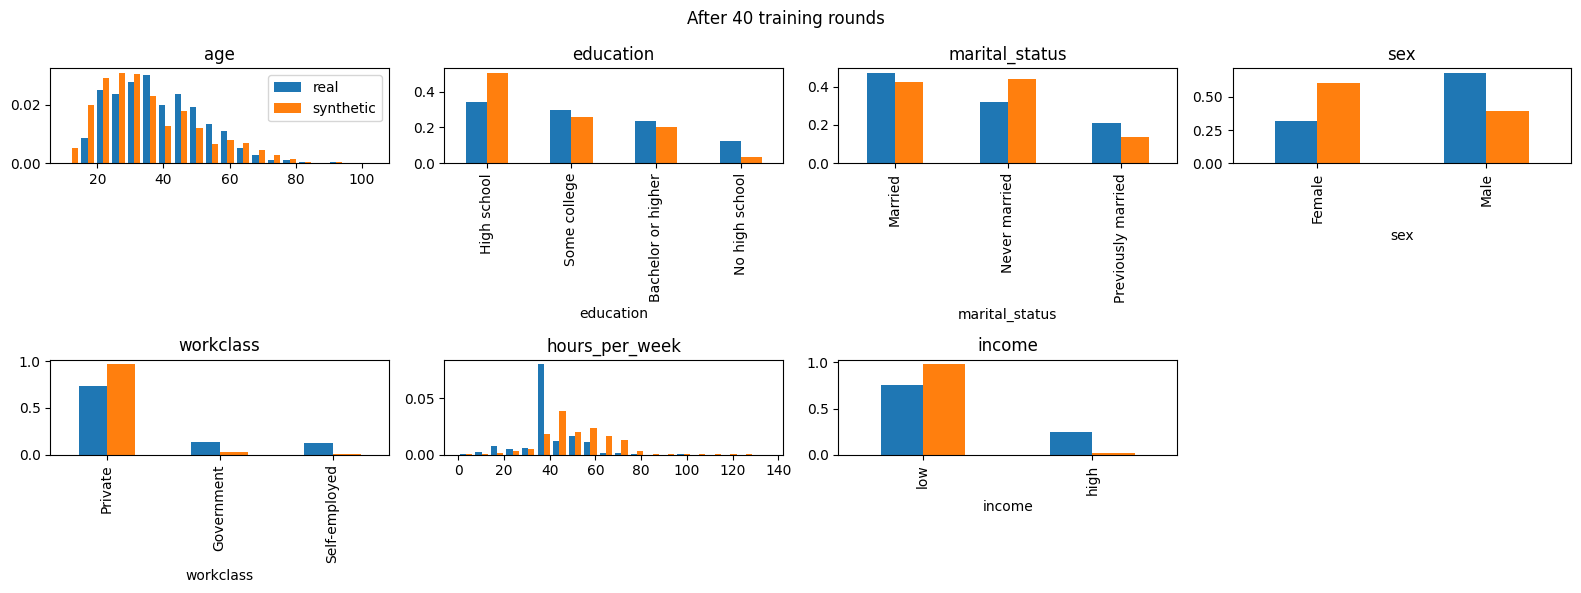

In [5]:
import matplotlib.pyplot as plt

def compare(real, synthetic, title):
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for ax, col in zip(axes.ravel(), real.columns):
        if real[col].dtype == object:
            pd.DataFrame({"real": real[col].value_counts(normalize=True),
                          "synthetic": synthetic[col].value_counts(normalize=True)}).plot.bar(ax=ax, legend=False)
        else:
            ax.hist([real[col], synthetic[col]], bins=20, density=True, label=["real", "synthetic"])
        ax.set_title(col)
    axes.ravel()[-1].axis("off")
    axes.ravel()[0].legend(["real", "synthetic"])
    fig.suptitle(title); plt.tight_layout(); plt.show()

compare(tabular_data, syn_data, "After 40 training rounds")

<!-- ## 6. Switch differential privacy on

Same model, `private=True`. The package now adds noise while it learns and prints the privacy guarantee **epsilon** after every round. Smaller epsilon means stronger privacy. Watch it grow as training continues. -->

In [ ]:
if os.path.exists("fitted_transformer.pkl"):
    os.remove("fitted_transformer.pkl")

private_model = DP_CGAN(epochs=30, batch_size=500, private=True, verbose=False, saved_transformer=None)
private_model.fit(tabular_data)

private_syn_data = private_model.sample(2000)
compare(tabular_data, private_syn_data, "After 40 training rounds, with differential privacy")

## 7. A generator trained longer

A generator usually needs many hundreds of rounds. We trained the same model for **1 000 rounds** before the workshop. Load it and compare: this is the quality you can expect from DP-CGANS on a small table.

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator BayesianGaussianMixture from version 1.9.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


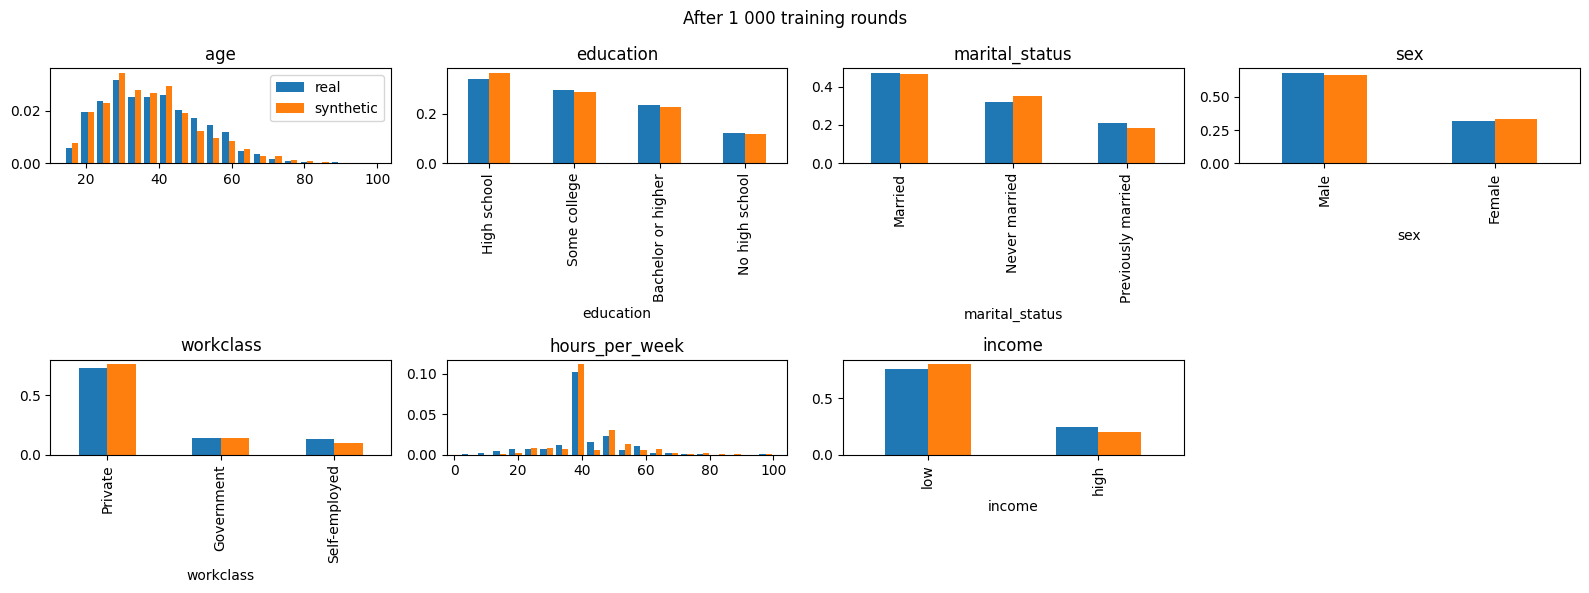

In [6]:
import urllib.request

urllib.request.urlretrieve("https://raw.githubusercontent.com/sunchang0124/syndata-workshop/main/models/dpcgan_best.pkl", "dpcgan_best.pkl")
trained_model = DP_CGAN.load("dpcgan_best.pkl")

syn_trained = trained_model.sample(len(tabular_data))
compare(tabular_data, syn_trained, "After 1 000 training rounds")

## 8. Would a statistician get the same answers?

Looking similar is not the point. The point is that an analysis done on the synthetic data leads to the same conclusions as on the real data. We run the same analyses on both and put the results side by side. We use 5 000 synthetic rows for stable estimates.

In [7]:
syn_trained = trained_model.sample(5000)
real = tabular_data

# 1. Descriptive statistics
pd.concat({"real": real.describe().T, "synthetic": syn_trained.describe().T}, axis=1).round(1)

real                                           synthetic  \
                 count  mean   std   min   25%   50%   75%   max     count   
age             2000.0  38.6  13.3  17.0  28.0  37.0  48.0  90.0    5000.0   
hours_per_week  2000.0  40.9  11.8   2.0  40.0  40.0  45.0  99.0    5000.0   

                                                           
                mean   std   min   25%   50%   75%    max  
age             38.3  13.9  13.0  28.0  36.0  46.0   97.0  
hours_per_week  42.9  10.1   8.0  40.0  40.0  49.0  101.0

In [8]:
# 2. Group comparison: are people with a high income older, and do they work more hours?
from scipy.stats import ttest_ind

def group_means(df):
    out = df.groupby("income")[["age", "hours_per_week"]].mean().T
    out["difference"] = out["high"] - out["low"]
    out["p-value"] = [ttest_ind(df.loc[df.income == "high", c], df.loc[df.income == "low", c]).pvalue for c in out.index]
    return out

pd.concat({"real": group_means(real), "synthetic": group_means(syn_trained)}, axis=1).round(3)

real                            synthetic          \
income            high     low difference p-value      high     low   
age             44.360  36.687      7.674     0.0    42.462  37.212   
hours_per_week  45.259  39.529      5.730     0.0    47.142  41.768   

                                   
income         difference p-value  
age                 5.250     0.0  
hours_per_week      5.373     0.0

In [9]:
# 3. Cross-tables: share of high income by education and by marital status
def share_high(df, col):
    return pd.crosstab(df[col], df["income"], normalize="index")["high"]

pd.concat({"real": pd.concat([share_high(real, "education"), share_high(real, "marital_status")]),
           "synthetic": pd.concat([share_high(syn_trained, "education"), share_high(syn_trained, "marital_status")])}, axis=1).round(2)

,real,synthetic
Bachelor or higher,0.49,0.47
High school,0.16,0.09
No high school,0.08,0.00
Some college,0.22,0.21
Married,0.44,0.33
Never married,0.05,0.07
Previously married,0.11,0.13


In [10]:
# 4. Which variables are associated with which? Cramér's V for every pair of categorical variables, strongest first
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(df):
    cats = [c for c in df.columns if df[c].dtype == object]
    out = {}
    for i, a in enumerate(cats):
        for b in cats[i + 1:]:
            table = pd.crosstab(df[a], df[b])
            chi2 = chi2_contingency(table)[0]
            out[f"{a} ~ {b}"] = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return pd.Series(out)

pd.concat({"real": cramers_v(real), "synthetic": cramers_v(syn_trained)}, axis=1).sort_values("real", ascending=False).round(2)

,real,synthetic
marital_status ~ sex,0.46,0.52
marital_status ~ income,0.43,0.30
education ~ income,0.33,0.39
sex ~ income,0.20,0.08
marital_status ~ workclass,0.12,0.17
sex ~ workclass,0.12,0.22
workclass ~ income,0.11,0.11
education ~ workclass,0.11,0.12
education ~ sex,0.08,0.13
education ~ marital_status,0.07,0.13


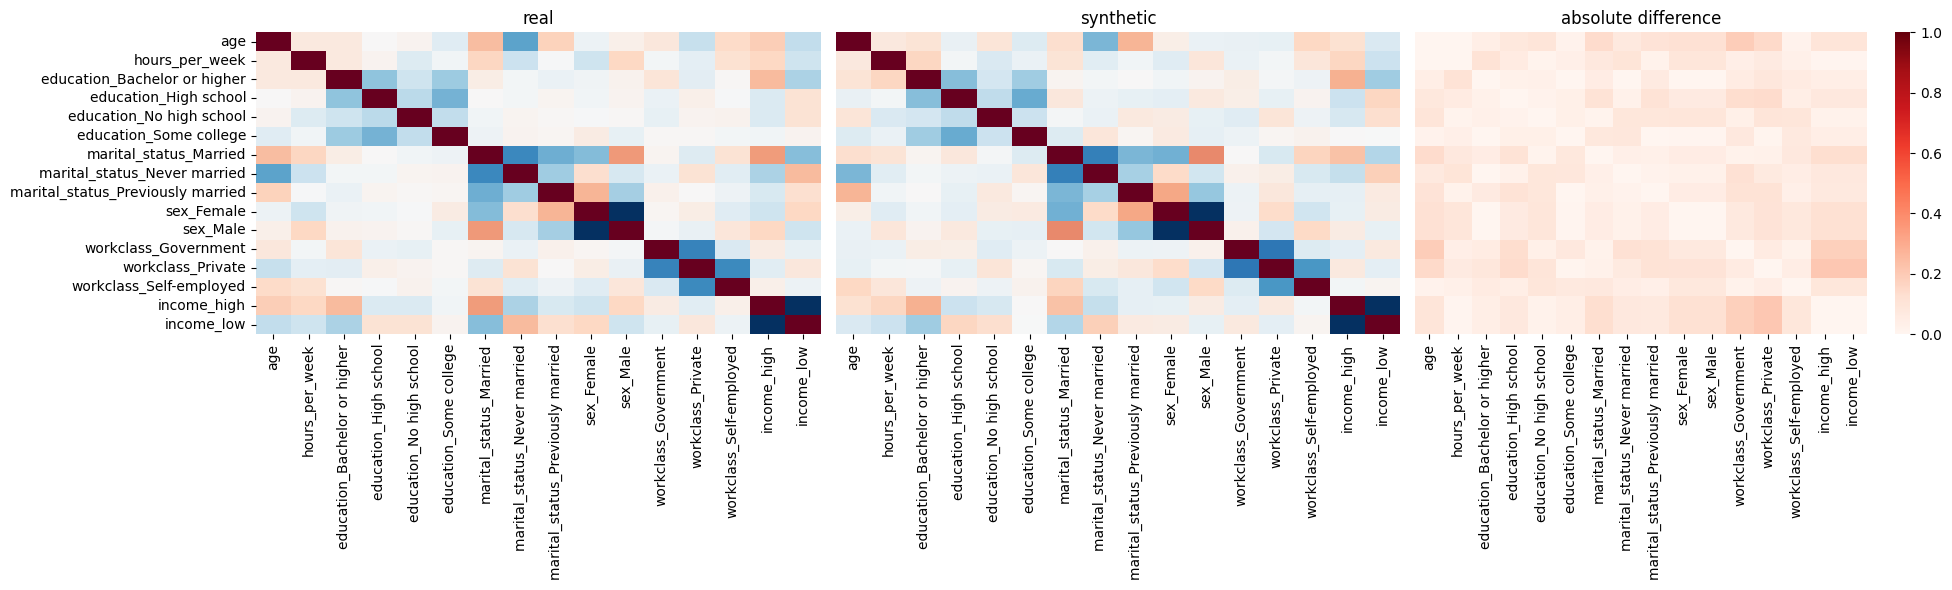

average absolute difference in correlation: 0.064 (0 = identical)


In [11]:
# 5. Correlations between all variables (categories turned into 0/1 columns): real, synthetic, and the difference
import seaborn as sns

real_corr = pd.get_dummies(real, dtype=float).corr()
syn_corr  = pd.get_dummies(syn_trained, dtype=float).corr().reindex_like(real_corr)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(real_corr, ax=axes[0], cmap="RdBu_r", vmin=-1, vmax=1, cbar=False); axes[0].set_title("real")
sns.heatmap(syn_corr,  ax=axes[1], cmap="RdBu_r", vmin=-1, vmax=1, cbar=False, yticklabels=False); axes[1].set_title("synthetic")
sns.heatmap((real_corr - syn_corr).abs(), ax=axes[2], cmap="Reds", vmin=0, vmax=1, yticklabels=False); axes[2].set_title("absolute difference")
plt.tight_layout(); plt.show()

print("average absolute difference in correlation:", round(float((real_corr - syn_corr).abs().mean().mean()), 3), "(0 = identical)")

### The same regression on both datasets

A logistic regression of high income on age, education and marital status, fitted once on the real data and once on the synthetic data. The plot shows each coefficient with its 95% confidence interval. If the synthetic data is useful, the dots sit close together and on the same side of zero.

In [ ]:
import statsmodels.formula.api as smf

formula = "high ~ age + C(education) + C(marital_status)"

def fit_logit(df):
    return smf.logit(formula, data=df.assign(high=(df["income"] == "high").astype(int))).fit(disp=0)

real_fit, syn_fit = fit_logit(real), fit_logit(syn_trained)

names = [n for n in real_fit.params.index if n != "Intercept"]
y = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 4))
for fit, offset, label in [(real_fit, 0.15, "real"), (syn_fit, -0.15, "synthetic")]:
    ci = fit.conf_int().loc[names]
    ax.errorbar(fit.params[names], y + offset, xerr=[fit.params[names] - ci[0], ci[1] - fit.params[names]], fmt="o", capsize=3, label=label)
ax.axvline(0, color="grey", lw=1); ax.set_yticks(y); ax.set_yticklabels(names); ax.set_xlabel("coefficient (log-odds of high income)")
ax.legend(); ax.set_title("Same logistic regression on real and synthetic data"); plt.tight_layout(); plt.show()

pd.DataFrame({"real": real_fit.params, "synthetic": syn_fit.params}).round(2)

**What to take from this**

* The conclusions match: high earners are older and work more hours, the income gradient over education levels is the same, married people earn more, and the regression coefficients agree in sign and size. A researcher could develop this analysis on the synthetic data and run the final version on the real data.
* Not everything survives. This generator reproduces the link between **sex** and income less well. Add `+ C(sex)` to the formula and see the coefficient shrink. That is exactly why synthetic data must be evaluated against the analysis you care about, not only on how it looks.

## 9. If you have time left

* Change `epochs=40` to `epochs=100` in step 3 and run steps 3 to 5 again.
* Ask for more rows than you had: `trained_model.sample(50000)`.
* Run the regression of step 8 on your own 40-round synthetic data (`fit_logit(syn_data)`) and on the private one. How wrong would your conclusions be?
* Add `+ C(sex)` to the regression formula in step 8. Which coefficient changes, and why might the generator miss it?
* Upload your own CSV with the cell below, **public or already anonymised data only**, and train on it. Keep it to about 10 columns with few categories each, or training gets slow.

In [ ]:
from google.colab import files
uploaded = files.upload()
my_data = pd.read_csv(next(iter(uploaded)))
my_data.head()

In [ ]:
# Download your synthetic data
files.download("syn_data_file.csv")

## Learn more

* `pip install dp-cgans` · https://github.com/sunchang0124/dp_cgans · https://pypi.org/project/dp-cgans/
* Sun C, van Soest J, Dumontier M. *Generating synthetic personal health data using conditional generative adversarial networks combining with differential privacy.* Journal of Biomedical Informatics 143 (2023) 104404.
* metasyn, the other tool in this workshop: https://metasyn.readthedocs.io
* Questions: chang.sun@maastrichtuniversity.nl